nam-data: 350000 frames
ensemble of 1 runs


/tmp/ipykernel_1872207/3844663630.py:124: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(specs, axis=0)


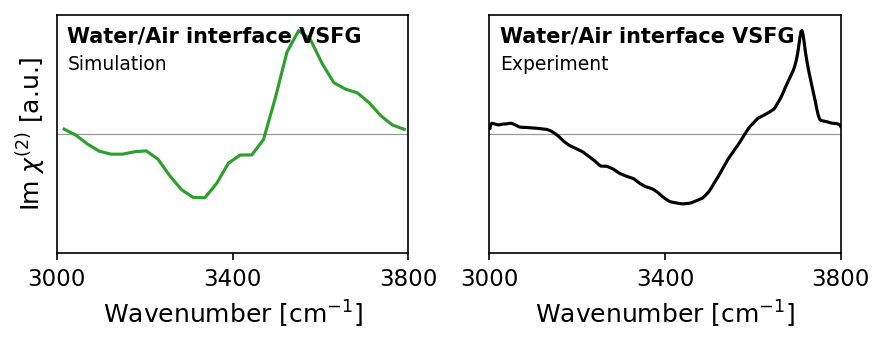

In [22]:
#!/usr/bin/env python
#   Im chi^(2)(w) ~ GLOBAL_SIGN * Re[cross] / w
#   cross = FT{ <alpha_xx(t) mu-dot_z(0)> }  (mu-dot already signum-mirrored upstream)
#   Ensemble: load the same-named .npz from several folders, one spectrum per
#   folder, then report mean +/- standard error across folders.

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import gaussian
from scipy.signal import convolve

# folders each containing a vsfg_series.npz (independent runs)
FOLDERS = [
    # "trial_1_vSFG",
    # "trial_2_vSFG",
    # "trial_3_vSFG",
    # "trial_4_vSFG",
    # "trial_5_vSFG",
]
NPZ_NAME    = "vsfg_series.npz"
EXP_CSV     = "./vSFG_Tang_Fig10_Tian_dashed.csv"   # Tang 2020 Fig10 (Tian, dashed); x=cm^-1, y=Im chi2
DT_FS       = 0.25
DLEN        = 5000
XMIN, XMAX  = 3000, 3800
WINDOW_SIZE = 30
SIGMA       = 1.5
GLOBAL_SIGN = 1.0          # flip to -1 if dangling-OH (~3700) is negative

EXP_SHIFT   = 0.0          # cm^-1 rigid shift of exp (e.g. +22 for QM-coherence, if desired)
EXP_SMOOTH_SIG = 2.0       # gaussian sigma (cm^-1) for light smoothing of digitized points


def fftcrosscorr(x, y, dlen=10000):
    if dlen % 2 == 0:
        dlen -= 1
    dt = x[1, 0] - x[0, 0]
    window = len(x) // dlen
    omega0 = 2.0 * np.pi / (dlen - 1) / dt
    c = np.zeros((dlen, 2), dtype=np.complex128)
    c[0:dlen // 2 + 1, 0] = np.arange(dlen // 2 + 1) * omega0
    c[dlen // 2 + 1:, 0] = np.arange(dlen // 2, 0, -1) * omega0 * -1
    for i in range(window):
        Ax = np.fft.fft(x[i * dlen:(i + 1) * dlen, 1])
        Ay = np.fft.fft(y[i * dlen:(i + 1) * dlen, 1])
        c[:, 1] += np.conjugate(Ax) * Ay / dlen * dt
    for i in range(window - 1):
        Ax = np.fft.fft(x[i * dlen + dlen // 2:(i + 1) * dlen + dlen // 2, 1])
        Ay = np.fft.fft(y[i * dlen + dlen // 2:(i + 1) * dlen + dlen // 2, 1])
        c[:, 1] += np.conjugate(Ax) * Ay / dlen * dt
    c[:, 1] /= (window * 2 - 1)
    return c


def smooth_signal(signal, window_size=30, sigma=1.5):
    kernel = gaussian(window_size, std=sigma)
    kernel /= np.sum(kernel)
    return convolve(signal, kernel, mode="same")


def pack(time_arr, sig):
    out = np.zeros((len(sig), 2), dtype=np.float64)
    out[:, 0] = time_arr
    out[:, 1] = sig - np.mean(sig)          # remove static (DC) part
    return out


def vsfg_spectrum(alpha_t, mudot_t, dt_fs, dlen):
    time_arr = np.arange(len(alpha_t), dtype=np.float64) * dt_fs
    Axx = pack(time_arr, alpha_t[:, 0, 0].astype(np.float64))
    Ayy = pack(time_arr, alpha_t[:, 1, 1].astype(np.float64))
    Mz  = pack(time_arr, mudot_t[:, 2].astype(np.float64))
    ft_xx = fftcrosscorr(Axx, Mz, dlen=dlen)
    ft_yy = fftcrosscorr(Ayy, Mz, dlen=dlen)
    omega_cm = np.real(ft_xx[:, 0]) * 1e15 / 2.99792458e10 / (2.0 * np.pi)
    cross = 0.5 * (ft_xx[:, 1] + ft_yy[:, 1])       # chi_xxz (= chi_yyz avg)
    w = omega_cm.copy()
    w[np.abs(w) < 1e-12] = np.nan
    im_chi2 = GLOBAL_SIGN * np.real(cross) / w       # (1/w) * Re[cross]
    return omega_cm, im_chi2


def spectrum_from_folder(folder, dlen):
    """Load folder/NPZ_NAME and return omega, Im chi2 for that run."""
    import os
    d = np.load(os.path.join(folder, NPZ_NAME))
    alpha_t = d["alpha_t"].astype(np.float64)
    mudot_t = d["mudot_t"].astype(np.float64)
    dt_fs   = float(d["DT_FS"]) if "DT_FS" in d else DT_FS
    omega_cm, im_chi2 = vsfg_spectrum(alpha_t, mudot_t, dt_fs, dlen)
    return omega_cm, im_chi2, len(alpha_t)


def load_exp(csv, xmin, xmax, shift=0.0, smooth_sig=6.0):
    data = np.loadtxt(csv, delimiter=",")
    x, y = data[:, 0] + shift, data[:, 1]
    order = np.argsort(x)
    x, y = x[order], y[order]
    lo, hi = max(xmin, x.min()), min(xmax, x.max())   # don't extrapolate past data
    xg = np.arange(lo, hi + 1.0, 2.0)
    yg = np.interp(xg, x, y)
    if smooth_sig and smooth_sig > 0:
        n = int(max(3, 6 * smooth_sig / 2.0))
        yg = smooth_signal(yg, window_size=n, sigma=smooth_sig / 2.0)
    return xg, yg


def main():
    # one spectrum per folder
    specs, omega_cm = [], None
    for folder in FOLDERS:
        omega_cm, s, nframes = spectrum_from_folder(folder, DLEN)
        specs.append(s)
        print(f"{folder}: {nframes} frames")
    n_runs = len(specs)
    print(f"ensemble of {n_runs} runs")

    pos = omega_cm >= 0
    omega_cm = omega_cm[pos]
    specs = np.array([smooth_signal(s[pos], WINDOW_SIZE, SIGMA) for s in specs])  # smooth each run
    mean = np.nanmean(specs, axis=0)
    sem  = np.nanstd(specs, axis=0) / np.sqrt(n_runs)                             # standard error

    band = (omega_cm >= XMIN) & (omega_cm <= XMAX)
    wb, cb, eb = omega_cm[band], mean[band], sem[band]

    # experiment
    ex, ey = load_exp(EXP_CSV, XMIN, XMAX, shift=EXP_SHIFT, smooth_sig=EXP_SMOOTH_SIG)

    # scale exp so its highest peak (max-abs) matches the simulation mean peak
    sim_peak = np.nanmax(np.abs(cb))
    exp_peak = np.nanmax(np.abs(ey))
    ey_scaled = ey * (sim_peak / exp_peak)

    ymax = 1.15 * max(np.nanmax(np.abs(cb) + np.abs(eb)), np.nanmax(np.abs(ey_scaled)))

    fig, axes = plt.subplots(1, 2, figsize=(6.0, 2.4), dpi=150, sharey=True)

    # left: MACELES with error band
    ax = axes[0]
    ax.axhline(0, color="k", lw=0.6, alpha=0.4)
    ax.fill_between(wb, cb - eb, cb + eb, color="tab:green", alpha=0.25, edgecolor="none")
    ax.plot(wb, cb, color="tab:green", lw=1.5)
    ax.set_ylabel(r"Im $\chi^{(2)}$ [a.u.]", fontsize=12)
    ax.text(0.03, 0.95, "Water/Air interface VSFG", transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="top", ha="left")
    ax.text(0.03, 0.83, "Simulation", transform=ax.transAxes,
            fontsize=9, va="top", ha="left")

    # right: Exp (black line)
    ax = axes[1]
    ax.axhline(0, color="k", lw=0.6, alpha=0.4)
    ax.plot(ex, ey_scaled, color="black", lw=1.5)
    ax.text(0.03, 0.95, "Water/Air interface VSFG", transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="top", ha="left")
    ax.text(0.03, 0.83, "Experiment", transform=ax.transAxes,
            fontsize=9, va="top", ha="left")

    for ax in axes:
        ax.set_xlim(XMIN, XMAX)
        ax.set_xticks([3000, 3400, 3800])
        ax.set_yticks([])
        ax.set_ylim(-ymax * 1, ymax * 1)
        ax.set_xlabel(r"Wavenumber [cm$^{-1}$]", fontsize=12)
        ax.tick_params(labelsize=11)

    plt.tight_layout()
    # plt.savefig("./vsfg_spectrum_exp_error_5.png", dpi=300, bbox_inches="tight")
    # plt.savefig("./vsfg_spectrum_exp_error_5.pdf", dpi=300, bbox_inches="tight", format="pdf")
    plt.show()


if __name__ == "__main__":
    main()